<a href="https://colab.research.google.com/github/KaisaridiSofia/leaspy_tutorial/blob/fit_notebook/notebooks/fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, sys
sys.path.insert(0, '/Users/sofia.kaisaridi/leaspy_v2_sk/src/')

import leaspy
leaspy.__version__

'2.1.0'

In [ ]:
import os

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")

os.makedirs("figures", exist_ok=True)

plt.rcParams.update({"font.family": "serif",
                     "axes.spines.top": False,
                     "axes.spines.right": False})

FEATURES = ["MDS1_total", "SCOPA_total", "MOCA_total"]
SEED = 0

leaspy 2.1.0


In [ ]:
df = load_dataset("parkinson")
df = df[FEATURES]
print(df[FEATURES].head())

n_subjects = df.index.get_level_values("ID").unique().shape[0]
print(f"{n_subjects} subjects in the dataset.")

# Train / test split
df_train = df.loc[:"GS-160"][FEATURES]
df_test = df.loc["GS-161":][FEATURES]
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)
train_ids = df_train.index.get_level_values("ID").unique()
test_ids = df_test.index.get_level_values("ID").unique()
print(f"Train : {len(train_ids)} subjects")
print(f"Test  : {len(test_ids)} subjects")

                  MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768
200 subjects in the dataset.
Train : 160 subjects
Test  : 40 subjects


In [ ]:
# --- Model initialization ---
model = LogisticModel(name="logistic", source_dimension=2)

#model.fit(
#        df_train, "mcmc_saem",
#        seed=SEED, n_iter=100000, progress_bar=True,
#        save_periodicity=500, plot_periodicity=500,
#        overwrite_logs_folder=True,
#    )


In [ ]:
##model.save("/Users/sofia.kaisaridi/leaspy_v2_sk/_outputs/model_parameters.json")

In [ ]:
#model.load("/Users/sofia.kaisaridi/leaspy_v2_sk/_outputs/model_parameters.json")

In [ ]:
model.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=500, plot_periodicity=500,
        overwrite_logs_folder=True,
    )


/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:86: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:86: UserWarning: The logs path you provided (/Users/sofia.kaisaridi/leaspy_v2_sk/_outputs) does not exist. Needed paths will be created (and their parents if needed).
  self._create_root_folder(settings)


|##################################################|   1000/1000 iterations

Fit with `mcmc_saem` took: 9.77s


In [ ]:
## convergence plot

In [ ]:
model.summary()

                                 Model Summary                                  
Model Name: logistic
Model Type: LogisticModel
Features (3): MDS1_total, SCOPA_total, MOCA_total
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5604.3721
Parameters: 19
BIC: -13544.90
AIC: -13603.33

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 1000

Data Context
--------------------------------------------------------------------------------
Subjects: 160
Visits: 1590
Total Observations: 4770
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1
            b0        0.0538    0.0269
            b1       -0.0486    0.0329
                    MDS1_to.  SCOPA_t.  MOCA_to.
  log_g_mean          1.8939    1.4229    2.2032
                 

## Convergence
Open the convergence pdf

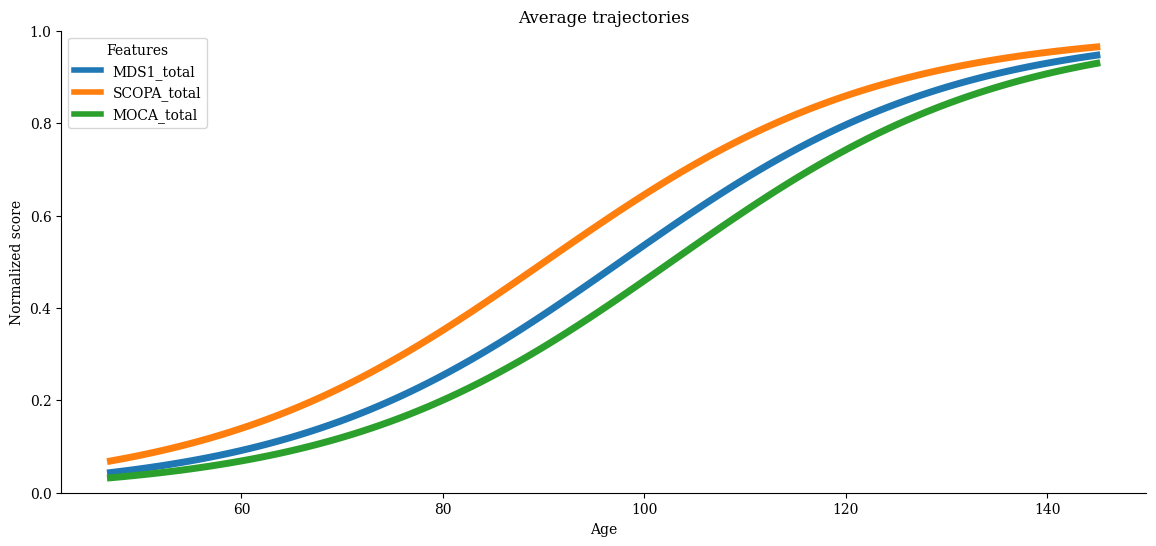

In [ ]:
leaspy_plotting = Plotting(model)
ax = leaspy_plotting.average_trajectory(alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8)
plt.show()

## Model Comparison

In [ ]:
model_1_source = LogisticModel(name="logistic", source_dimension=1)

model_1_source.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=500, plot_periodicity=500,
        overwrite_logs_folder=True,
    )

|#-------------------------------------------------|   20/1000 iterations

/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:86: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:167: UserWarning: Overwriting '/Users/sofia.kaisaridi/leaspy_v2_sk/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|##################################################|   1000/1000 iterations

Fit with `mcmc_saem` took: 8.74s


In [ ]:
model_1_source.summary().bic

-12507.642922081259

In [ ]:
model.summary().bic

-13544.896892823057

In [ ]:
model_scalar = LogisticModel(name="logistic", source_dimension=1, obs_models='gaussian-scalar')

model_scalar.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=500, plot_periodicity=500,
        overwrite_logs_folder=True,
    )

|--------------------------------------------------|   0/1000 iterations

/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/models/time_reparametrized.py:295: UserWarning: You chose `gaussian-scalar` noise but the dataset has 3 features: a single noise_std will be shared across all features.
  warnings.warn(
/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:86: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/sofia.kaisaridi/leaspy_v2_sk/src/leaspy/algo/settings.py:167: UserWarning: Overwriting '/Users/sofia.kaisaridi/leaspy_v2_sk/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|##################################################|   1000/1000 iterations

Fit with `mcmc_saem` took: 8.66s


In [ ]:
model_scalar.summary().bic

-12437.191750206259